In [2]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import gseapy as gp
from collections import defaultdict

plt.rcParams['figure.dpi'] = 200

CMAP = "#2563eb"

In [4]:
CN     = pd.read_csv("centrality_core/core_nodes.csv")
CE     = pd.read_csv("centrality_core/core_edges.csv")
H_core = sp.load_npz("centrality_core/H_core.npz")   # rows = CN, cols = CE

print(f"CN: {len(CN)} core nodes")
print(f"CE: {len(CE)} core edges")
print(f"H_core: {H_core.shape}")
print(f"\nCN columns:  {CN.columns.tolist()}")
print(f"CE columns:  {CE.columns.tolist()}")

CN: 467 core nodes
CE: 62447 core edges
H_core: (467, 62447)

CN columns:  ['bin_name', 'chrom', 'bin_start', 'bin_end', 'global_hge_logexp_unweighted', 'is_core']
CE columns:  ['read_index', 'basename', 'mean_mapq', 'median_mapq', 'n_chromosomes', 'order', 'n_bins', 'read_length_bp', 'genes', 'n_genes']


In [6]:
def parse_genes(series):
    """Flatten a column of comma/semicolon-separated gene strings into a set."""
    genes = set()
    for val in series.dropna():
        for g in str(val).replace(";", ",").split(","):
            g = g.strip()
            if g and g != "nan":
                genes.add(g)
    return genes

# Genes overlapping core nodes (loci)
#cn_genes = parse_genes(CN["genes"])

# Genes overlapping core edges (reads) — usually richer
ce_genes = parse_genes(CE["genes"])

# Union
#all_core_genes = cn_genes | ce_genes
all_core_genes = ce_genes

#print(f"Genes in CN loci:       {len(cn_genes)}")
print(f"Genes in CE hyperedges: {len(ce_genes)}")
print(f"Union:                  {len(all_core_genes)}")

Genes in CE hyperedges: 9467
Union:                  9467


In [7]:
# Map each CN row index to its chromosome
cn_chrom = CN["chrom"].values   # length = H_core.shape[0]

H_csc = H_core.tocsc()

edge_stats = []
for j in range(H_csc.shape[1]):
    col     = H_csc[:, j]
    members = col.nonzero()[0]           # CN row indices in this hyperedge
    chroms  = set(cn_chrom[members])
    edge_stats.append({
        "edge_idx":    j,
        "n_nodes":     len(members),
        "n_chroms":    len(chroms),
        "chroms":      ",".join(sorted(chroms)),
        "is_inter":    len(chroms) > 1,
    })

edge_df = pd.DataFrame(edge_stats)

n_intra = (~edge_df["is_inter"]).sum()
n_inter = edge_df["is_inter"].sum()
print(f"Intra-chromosomal CE: {n_intra} ({100*n_intra/len(edge_df):.1f}%)")
print(f"Inter-chromosomal CE: {n_inter} ({100*n_inter/len(edge_df):.1f}%)")

Intra-chromosomal CE: 32581 (52.2%)
Inter-chromosomal CE: 29866 (47.8%)


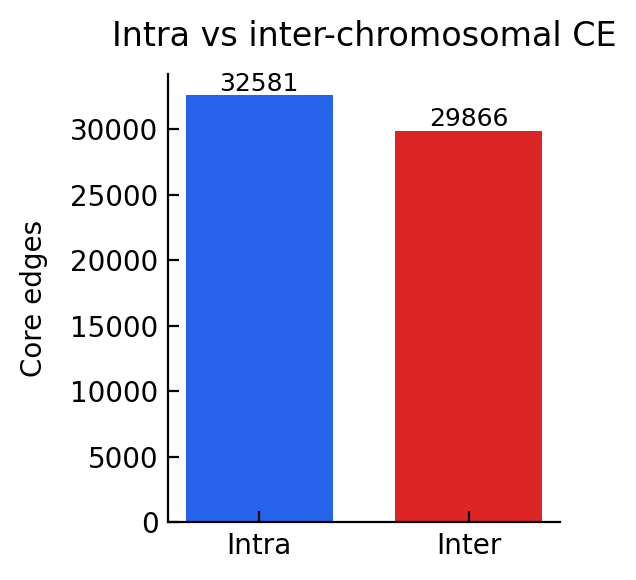

In [22]:
fig, ax = plt.subplots(figsize=(3, 3))

counts = [n_intra, n_inter]
labels = ["Intra", "Inter"]
colors = ["#2563eb", "#dc2626"]

ax.bar(labels, counts, color=colors, edgecolor="none", width=0.7)
ax.set_ylabel("Core edges", labelpad=8)
ax.set_title("Intra vs inter-chromosomal CE", pad=10, loc="center")
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(direction="in", length=4, width=0.8)

for i, v in enumerate(counts):
    ax.text(i, v + max(counts)*0.01, str(v), ha="center", fontsize=9)

plt.tight_layout()
#plt.savefig("core_intra_inter_bar.pdf", bbox_inches="tight")
plt.show()

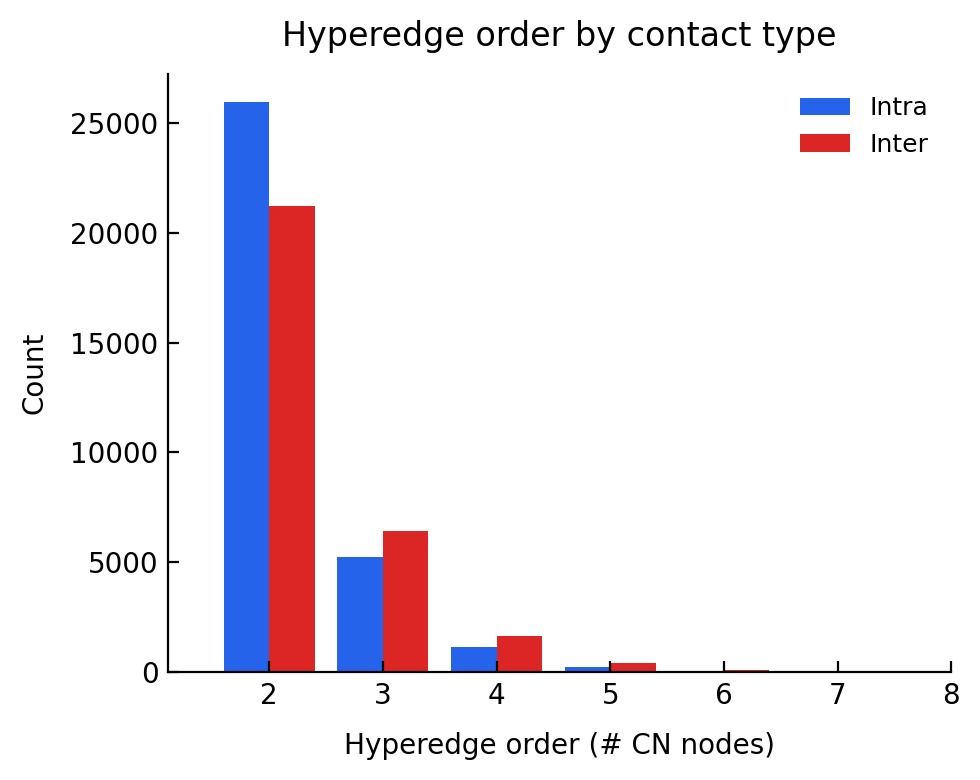

In [46]:
fig, ax = plt.subplots(figsize=(5, 4))

bins     = np.arange(2, 12)
intra    = edge_df[~edge_df["is_inter"]]["n_nodes"].values
inter    = edge_df[edge_df["is_inter"]]["n_nodes"].values
width    = 0.4

intra_counts = np.array([(intra == b).sum() for b in bins])
inter_counts = np.array([(inter == b).sum() for b in bins])

ax.bar(bins - width/2, intra_counts, width=width, color="#2563eb", label="Intra", edgecolor="none")
ax.bar(bins + width/2, inter_counts, width=width, color="#dc2626", label="Inter", edgecolor="none")

ax.set_xlabel("Hyperedge order (# CN nodes)", labelpad=8)
ax.set_ylabel("Count", labelpad=8)
ax.set_title("Hyperedge order by contact type", pad=10, loc="center")
ax.set_xlim(right=8)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(direction="in", length=4, width=0.8)

plt.tight_layout()
plt.show()

In [24]:
inter_edges = edge_df[edge_df["is_inter"]]
chrom_pairs = defaultdict(int)
for _, row in inter_edges.iterrows():
    chroms = sorted(row["chroms"].split(","))
    for i in range(len(chroms)):
        for j in range(i+1, len(chroms)):
            chrom_pairs[(chroms[i], chroms[j])] += 1

all_chroms = sorted(CN["chrom"].unique(),
                    key=lambda x: int(x.replace("chr","")) if x.replace("chr","").isdigit() else 100)
n_chr = len(all_chroms)
chrom_idx = {c: i for i, c in enumerate(all_chroms)}
mat = np.zeros((n_chr, n_chr))
for (a, b), cnt in chrom_pairs.items():
    if a in chrom_idx and b in chrom_idx:
        i, j = chrom_idx[a], chrom_idx[b]
        mat[i, j] = cnt
        mat[j, i] = cnt

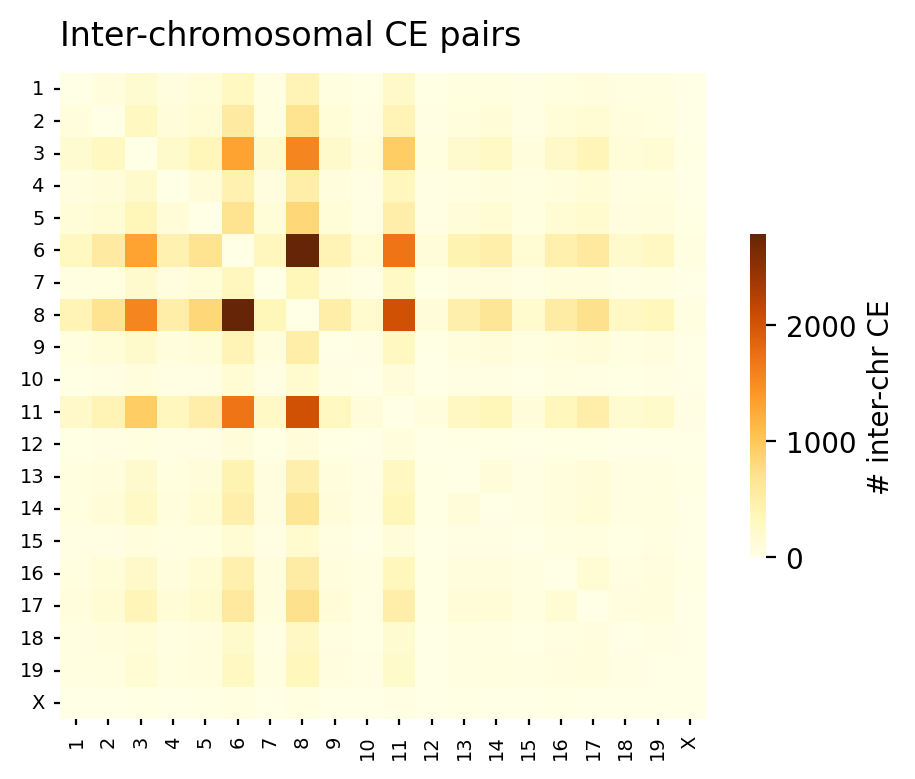

In [27]:
fig, ax = plt.subplots(figsize=(5, 4))

sns.heatmap(
    mat,
    cmap="YlOrBr",
    square=True,
    xticklabels=all_chroms,
    yticklabels=all_chroms,
    linewidths=0,
    cbar_kws={"shrink": 0.5, "label": "# inter-chr CE"},
    ax=ax,
)
ax.set_title("Inter-chromosomal CE pairs", pad=10, loc="left")
ax.tick_params(labelsize=7, length=2)

plt.tight_layout()
#plt.savefig("core_interchrom_heatmap.pdf", bbox_inches="tight")
plt.show()

In [47]:
LIBRARIES = [
    "KEGG_2019_Mouse",
    "GO_Biological_Process_2023",
    "Reactome_2022",
    "MSigDB_Hallmark_2020",
]

gene_list = sorted(all_core_genes)
print(f"Submitting {len(gene_list)} genes to Enrichr...")

enr_results = {}
for lib in LIBRARIES:
    enr = gp.enrichr(
        gene_list=gene_list,
        gene_sets=lib,
        organism="mouse",
        outdir=None,
        verbose=False,
    )
    enr_results[lib] = enr.results
    sig = enr.results[enr.results["Adjusted P-value"] < 0.05]
    print(f"  {lib}: {len(sig)} significant terms")

Submitting 9467 genes to Enrichr...
  KEGG_2019_Mouse: 0 significant terms
  GO_Biological_Process_2023: 0 significant terms
  Reactome_2022: 0 significant terms
  MSigDB_Hallmark_2020: 0 significant terms


In [48]:
N_TERMS = 15

for lib, df in enr_results.items():
    df = df[df["Adjusted P-value"] < 0.05].copy()
    if df.empty:
        print(f"No significant terms: {lib}")
        continue

    df["-log10(FDR)"] = -np.log10(df["Adjusted P-value"].clip(lower=1e-300))
    df = df.nsmallest(N_TERMS, "Adjusted P-value")

    fig, ax = plt.subplots(figsize=(7, max(3, len(df) * 0.35)))
    ax.barh(df["Term"], df["-log10(FDR)"], color=CMAP, edgecolor="none")
    ax.axvline(-np.log10(0.05), color="black", lw=0.8, ls="--", label="FDR=0.05")
    ax.set_xlabel("-log10(FDR)", labelpad=8)
    ax.set_title(lib.replace("_", " "), pad=10, loc="left")
    ax.invert_yaxis()
    ax.spines[["top","right"]].set_visible(False)
    ax.tick_params(labelsize=8)
    ax.legend(frameon=False, fontsize=8)
    plt.tight_layout()
    plt.savefig(f"gsea_{lib}.pdf", bbox_inches="tight")
    plt.show()

No significant terms: KEGG_2019_Mouse
No significant terms: GO_Biological_Process_2023
No significant terms: Reactome_2022
No significant terms: MSigDB_Hallmark_2020


In [ ]:
# Load a TF gene list 
# with open("tf_list.txt") as f:
#     tf_set = {l.strip() for l in f if l.strip()}

tf_set = set()   # placeholder

cn_tfs  = cn_genes  & tf_set
ce_tfs  = ce_genes  & tf_set
all_tfs = all_core_genes & tf_set

print(f"TFs in CN loci:       {len(cn_tfs)}")
print(f"TFs in CE hyperedges: {len(ce_tfs)}")
print(f"Union:                {len(all_tfs)}")
print(f"\nTFs found:\n{sorted(all_tfs)}")

In [ ]:
if all_tfs:
    # Which chromosomes do TF-containing CN loci sit on?
    tf_cn = CN[CN["genes"].apply(
        lambda x: bool(parse_genes(pd.Series([x])) & tf_set) if pd.notna(x) else False
    )]

    tf_per_chrom = tf_cn.groupby("chrom").size().reindex(all_chroms, fill_value=0)

    fig, ax = plt.subplots(figsize=(10, 3.5))
    ax.bar(tf_per_chrom.index, tf_per_chrom.values, color=CMAP, edgecolor="none")
    ax.set_xlabel("Chromosome", labelpad=8)
    ax.set_ylabel("TF-containing CN loci", labelpad=8)
    ax.set_title("TF distribution across core nodes", pad=10, loc="left")
    ax.spines[["top","right"]].set_visible(False)
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    plt.tight_layout()
    plt.savefig("core_tf_distribution.pdf", bbox_inches="tight")
    plt.show()
else:
    print("Load a TF list in Cell 6 first.")